In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#file and function imports

#library imports
#0.
import nltk
from nltk.corpus import nps_chat
nltk.download('nps_chat')
from collections import defaultdict

#1. 2.
nltk.download('punkt')
import importlib
import matplotlib.pyplot as plt
import src.stopwords as stopwordStats
importlib.reload(stopwordStats)
import pandas as pd

#3. 4.
import src.stats as stats
importlib.reload(stats)
import spacy
nlp = spacy.load("en_core_web_sm")
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

[nltk_data] Downloading package nps_chat to
[nltk_data]     C:\Users\egets\AppData\Roaming\nltk_data...
[nltk_data]   Package nps_chat is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\egets\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\egets\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\egets\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# task 0 
# pull in and preprocess the data
print(nltk.corpus.nps_chat.words())

texts = nps_chat.xml_posts()

dialogueGroups = defaultdict(list)
#dialogue act subgroupings
for i in texts:
    attributeType = i.attrib['class']
    if i.text:
        dialogueGroups[attributeType].append(i.text)

print(dialogueGroups.keys())
print(dialogueGroups['Statement'])


['now', 'im', 'left', 'with', 'this', 'gay', 'name', ...]
dict_keys(['Statement', 'Emotion', 'System', 'Greet', 'Accept', 'Reject', 'whQuestion', 'Continuer', 'ynQuestion', 'yAnswer', 'Bye', 'Clarify', 'Emphasis', 'nAnswer', 'Other'])
['now im left with this gay name', 'ah well', '26/ m/ ky women that are nice please pm me', 'there ya go 10-19-20sUser7', "i'll thunder clap your ass.", 'that sounds painful', '26/m', 'my cousin drew a messed up pic on my cast', '24/m', '26/m and sexy', 'he drew a girl with legs spread', 'hope he didnt draw a penis', "I'll take one, please.", '& i have to go to the docs tomorrow', 'I am too.. Connected to... Slip away... Fade away... Days away I... Still feel you... Touching me... Changing me... Considerably killing me... ', '26/m', "you're back 10-19-20sUser115", '10-19-20sUser129', '10-19-20sUser115', 'hurry ladies', 'not fast enough 10-19-20sUser116', 'a bowl i got a blunt an a bong......lol', 'well, glad it worked out', 'my chair is too hard.', '10-19

Statement
proportion of stopwords to tokens in Statement: 0.3576709796672828
[('i', 899), ('to', 382), ('the', 372), ('a', 347), ('you', 336), ('me', 295), ('it', 227), ('in', 214), ('and', 200), ('that', 186), ('my', 186), ('is', 186), ('of', 122), ('for', 116), ('on', 115), ('was', 107), ('have', 100), ('here', 98), ('just', 96), ('so', 90), ('if', 86), ('too', 83), ('be', 83), ('not', 79), ('out', 74), ('do', 72), ('with', 70), ('your', 70), ('up', 69), ('there', 66), ('all', 66), ('now', 63), ('but', 62), ('can', 61), ('am', 59), ('no', 59), ('are', 58), ('he', 58), ('at', 56), ('they', 51), ('its', 50), ('about', 44), ('what', 43), ('this', 42), ('an', 42), ('we', 42), ('from', 42), ('or', 41), ('had', 40), ('she', 40), ('her', 38), ('some', 38), ('when', 37), ('as', 36), ('any', 33), ('only', 30), ('off', 30), ('then', 29), ('did', 29), ('been', 29), ('will', 29), ('m', 28), ('him', 27), ('how', 25), ('were', 24), ('over', 23), ('more', 22), ('his', 20), ('should', 18), ('down', 

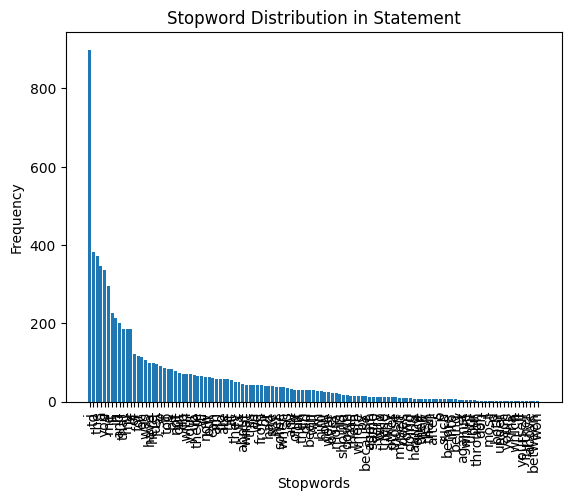

Emotion
proportion of stopwords to tokens in Emotion: 0.03216278306531014
[('here', 8), ('o', 7), ('i', 6), ('you', 6), ('her', 6), ('for', 5), ('to', 5), ('my', 4), ('the', 4), ('no', 3), ('it', 3), ('have', 3), ('there', 2), ('out', 2), ('too', 2), ('has', 2), ('so', 2), ('same', 2), ('that', 2), ('just', 2), ('should', 2), ('me', 2), ('this', 1), ('him', 1), ('how', 1), ('in', 1), ('am', 1), ('we', 1), ('up', 1), ('yours', 1), ('he', 1), ('be', 1), ('and', 1), ('doing', 1), ('what', 1), ('is', 1), ('from', 1), ('m', 1), ('both', 1), ('d', 1)]


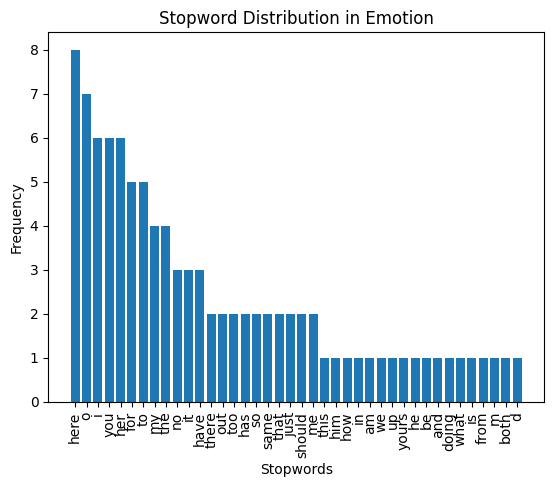

System
proportion of stopwords to tokens in System: 0.13955017756148888
[('the', 102), ('to', 91), ('a', 70), ('is', 52), ('and', 44), ('in', 43), ('of', 35), ('it', 33), ('i', 31), ('you', 30), ('on', 28), ('this', 24), ('for', 23), ('with', 23), ('up', 22), ('my', 22), ('your', 19), ('her', 17), ('has', 17), ('that', 15), ('at', 14), ('been', 13), ('his', 12), ('or', 12), ('what', 12), ('all', 11), ('out', 11), ('as', 11), ('their', 10), ('not', 9), ('have', 8), ('over', 8), ('do', 7), ('some', 7), ('an', 6), ('if', 6), ('them', 6), ('too', 6), ('they', 6), ('own', 6), ('am', 6), ('me', 6), ('again', 5), ('down', 5), ('no', 5), ('by', 5), ('before', 5), ('can', 5), ('our', 5), ('just', 5), ('so', 5), ('but', 4), ('she', 4), ('now', 4), ('had', 4), ('here', 4), ('himself', 4), ('was', 4), ('will', 3), ('does', 3), ('from', 3), ('be', 3), ('there', 3), ('when', 3), ('who', 3), ('about', 3), ('off', 3), ('any', 3), ('him', 2), ('he', 2), ('only', 2), ('then', 2), ('very', 2), ('more', 2

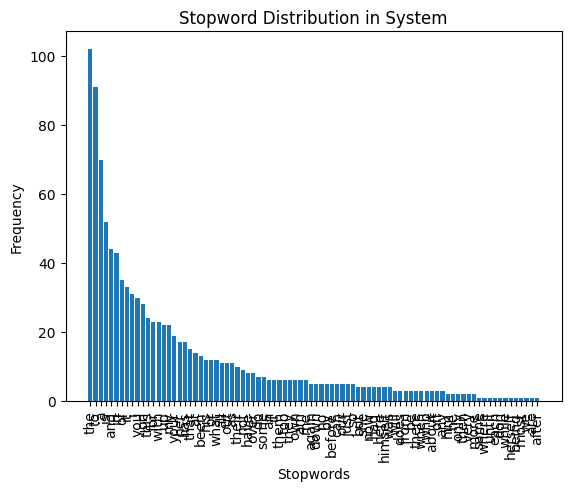

Greet
proportion of stopwords to tokens in Greet: 0.059935990689554845
[('all', 39), ('to', 27), ('there', 18), ('up', 15), ('and', 13), ('you', 9), ('my', 8), ('how', 5), ('here', 5), ('the', 4), ('i', 4), ('who', 4), ('me', 4), ('so', 3), ('as', 3), ('for', 3), ('in', 3), ('are', 3), ('its', 2), ('from', 2), ('what', 2), ('of', 2), ('at', 2), ('m', 2), ('is', 2), ('just', 2), ('they', 2), ('again', 2), ('should', 1), ('her', 1), ('have', 1), ('been', 1), ('did', 1), ('if', 1), ('it', 1), ('too', 1), ('doing', 1), ('he', 1), ('was', 1), ('any', 1), ('out', 1), ('but', 1), ('now', 1), ('were', 1)]


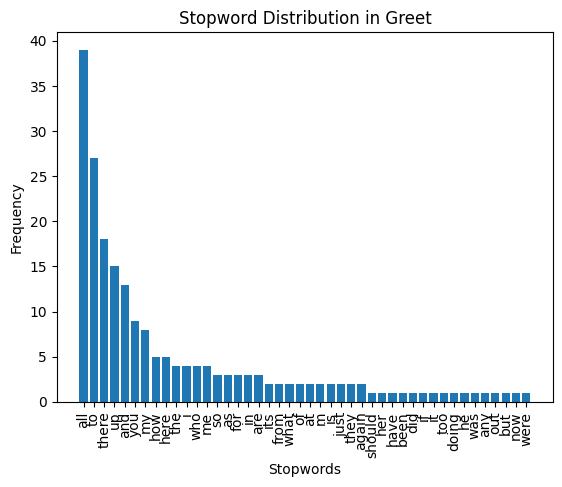

Accept
proportion of stopwords to tokens in Accept: 0.2706855791962175
[('i', 39), ('it', 15), ('too', 12), ('is', 10), ('that', 10), ('me', 9), ('you', 8), ('do', 7), ('a', 6), ('to', 6), ('so', 5), ('the', 5), ('for', 5), ('on', 4), ('he', 4), ('have', 4), ('there', 4), ('am', 3), ('its', 3), ('are', 3), ('with', 3), ('they', 3), ('does', 3), ('was', 3), ('no', 3), ('be', 3), ('all', 3), ('as', 2), ('should', 2), ('then', 2), ('of', 2), ('can', 2), ('not', 2), ('same', 2), ('here', 2), ('o', 2), ('at', 2), ('just', 2), ('but', 2), ('did', 1), ('how', 1), ('him', 1), ('his', 1), ('very', 1), ('your', 1), ('and', 1), ('or', 1), ('who', 1), ('what', 1), ('this', 1), ('will', 1), ('few', 1), ('in', 1), ('both', 1), ('some', 1), ('out', 1), ('my', 1), ('we', 1), ('why', 1), ('had', 1), ('where', 1)]


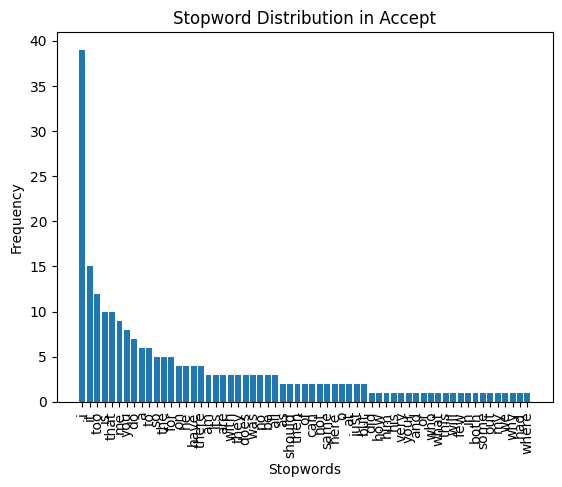

Reject
proportion of stopwords to tokens in Reject: 0.3754116355653128
[('no', 44), ('not', 38), ('i', 29), ('you', 19), ('the', 15), ('do', 14), ('me', 12), ('that', 11), ('up', 10), ('to', 10), ('it', 8), ('have', 8), ('a', 7), ('and', 7), ('my', 6), ('in', 6), ('out', 6), ('your', 6), ('with', 5), ('for', 5), ('is', 4), ('just', 4), ('are', 4), ('here', 4), ('they', 4), ('but', 4), ('too', 3), ('there', 3), ('be', 3), ('were', 3), ('on', 3), ('am', 2), ('can', 2), ('of', 2), ('if', 2), ('all', 2), ('so', 2), ('about', 2), ('what', 2), ('we', 2), ('any', 1), ('more', 1), ('had', 1), ('did', 1), ('most', 1), ('or', 1), ('him', 1), ('off', 1), ('does', 1), ('some', 1), ('will', 1), ('themselves', 1), ('through', 1), ('then', 1), ('again', 1), ('this', 1), ('into', 1), ('s', 1), ('own', 1)]


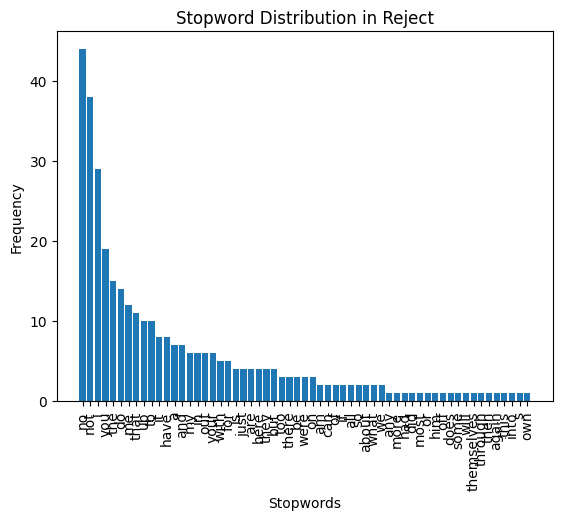

whQuestion
proportion of stopwords to tokens in whQuestion: 0.39932577382776585
[('what', 129), ('you', 106), ('how', 96), ('who', 76), ('are', 70), ('the', 63), ('is', 57), ('to', 45), ('why', 45), ('where', 43), ('and', 32), ('do', 28), ('in', 28), ('up', 26), ('did', 25), ('a', 23), ('i', 22), ('that', 21), ('so', 19), ('from', 18), ('about', 18), ('me', 15), ('it', 15), ('for', 14), ('was', 14), ('of', 14), ('here', 13), ('on', 12), ('your', 12), ('all', 12), ('doing', 11), ('when', 10), ('been', 10), ('we', 9), ('but', 8), ('not', 8), ('with', 8), ('there', 7), ('have', 7), ('they', 6), ('or', 6), ('at', 6), ('he', 5), ('does', 5), ('which', 5), ('were', 4), ('if', 4), ('my', 4), ('this', 4), ('can', 4), ('just', 3), ('should', 3), ('now', 3), ('same', 3), ('into', 3), ('am', 3), ('him', 2), ('her', 2), ('yourself', 2), ('other', 2), ('too', 2), ('as', 2), ('its', 2), ('then', 2), ('be', 2), ('over', 2), ('these', 2), ('any', 2), ('by', 2), ('an', 2), ('yours', 1), ('ll', 1), ('ha

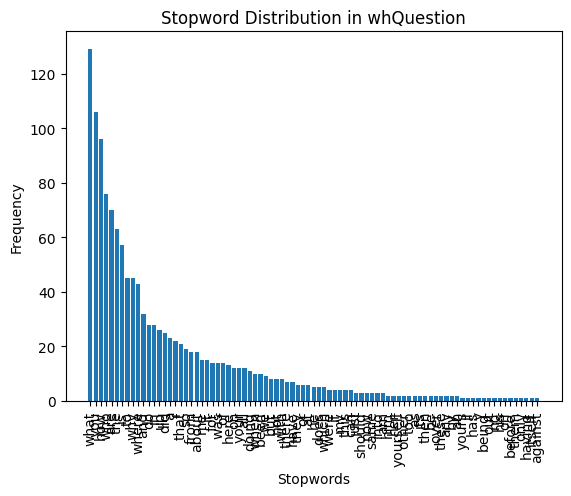

Continuer
proportion of stopwords to tokens in Continuer: 0.428343949044586
[('and', 32), ('i', 29), ('the', 19), ('to', 15), ('a', 14), ('you', 12), ('or', 11), ('but', 10), ('do', 8), ('not', 7), ('it', 7), ('that', 5), ('me', 5), ('of', 5), ('in', 5), ('on', 5), ('at', 4), ('is', 3), ('with', 3), ('my', 3), ('be', 3), ('if', 3), ('what', 2), ('between', 2), ('her', 2), ('about', 2), ('can', 2), ('he', 2), ('just', 2), ('for', 2), ('where', 2), ('from', 2), ('too', 2), ('o', 2), ('am', 2), ('some', 2), ('was', 2), ('t', 2), ('your', 2), ('out', 2), ('as', 2), ('all', 2), ('being', 1), ('very', 1), ('most', 1), ('should', 1), ('had', 1), ('during', 1), ('up', 1), ('over', 1), ('then', 1), ('how', 1), ('they', 1), ('under', 1), ('we', 1), ('will', 1), ('more', 1), ('than', 1), ('so', 1), ('when', 1), ('there', 1), ('have', 1), ('this', 1)]


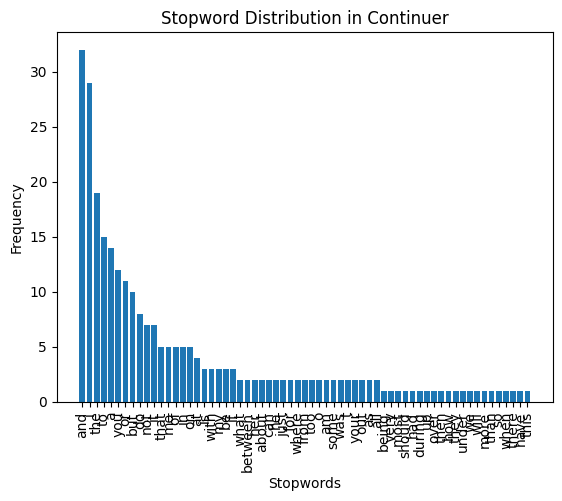

ynQuestion
proportion of stopwords to tokens in ynQuestion: 0.3200842326928139
[('you', 117), ('any', 87), ('a', 66), ('me', 59), ('i', 54), ('to', 53), ('is', 45), ('the', 44), ('in', 42), ('are', 36), ('here', 35), ('with', 34), ('do', 30), ('did', 27), ('from', 23), ('can', 23), ('have', 22), ('your', 20), ('that', 20), ('it', 18), ('or', 17), ('not', 15), ('and', 15), ('of', 15), ('there', 15), ('does', 13), ('no', 11), ('on', 11), ('too', 10), ('up', 10), ('for', 10), ('he', 9), ('out', 9), ('so', 9), ('be', 8), ('off', 7), ('all', 7), ('am', 6), ('this', 6), ('at', 6), ('she', 6), ('who', 6), ('how', 6), ('they', 6), ('some', 6), ('we', 6), ('him', 5), ('if', 5), ('what', 5), ('my', 5), ('m', 4), ('was', 4), ('an', 4), ('now', 4), ('her', 4), ('them', 4), ('by', 4), ('has', 4), ('will', 4), ('were', 4), ('more', 4), ('just', 4), ('but', 3), ('over', 3), ('down', 3), ('own', 2), ('being', 2), ('then', 2), ('having', 2), ('been', 2), ('few', 2), ('when', 2), ('again', 2), ('won', 2

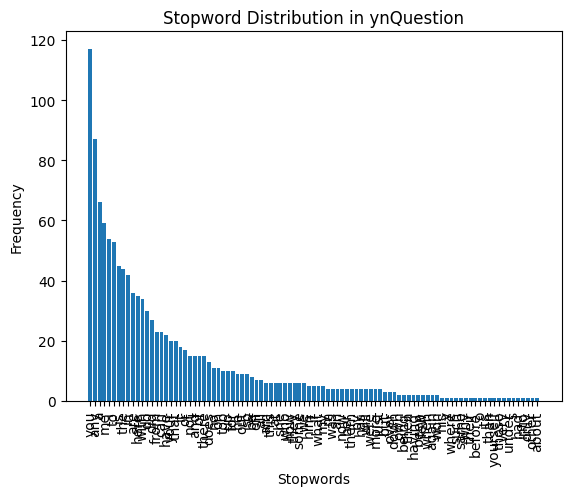

yAnswer
proportion of stopwords to tokens in yAnswer: 0.30787589498806683
[('i', 20), ('it', 7), ('the', 7), ('is', 6), ('am', 6), ('my', 5), ('why', 4), ('they', 4), ('me', 3), ('and', 3), ('too', 3), ('you', 3), ('its', 3), ('all', 3), ('not', 3), ('no', 3), ('do', 2), ('should', 2), ('he', 2), ('to', 2), ('other', 2), ('your', 2), ('at', 2), ('in', 2), ('of', 2), ('can', 2), ('did', 2), ('a', 2), ('this', 2), ('that', 2), ('here', 1), ('or', 1), ('so', 1), ('be', 1), ('her', 1), ('does', 1), ('we', 1), ('have', 1), ('about', 1), ('more', 1), ('than', 1), ('were', 1), ('being', 1), ('with', 1), ('only', 1), ('had', 1), ('between', 1), ('now', 1)]


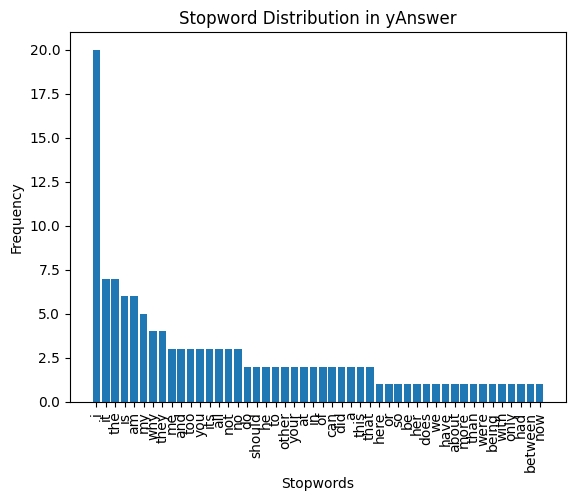

Bye
proportion of stopwords to tokens in Bye: 0.17403708987161198
[('all', 15), ('i', 13), ('a', 12), ('to', 10), ('have', 8), ('is', 6), ('here', 5), ('you', 4), ('off', 4), ('now', 4), ('my', 4), ('the', 3), ('in', 3), ('do', 2), ('again', 2), ('over', 2), ('and', 2), ('up', 2), ('me', 2), ('out', 2), ('your', 2), ('were', 1), ('where', 1), ('he', 1), ('it', 1), ('who', 1), ('not', 1), ('other', 1), ('that', 1), ('so', 1), ('few', 1), ('with', 1), ('when', 1), ('some', 1), ('for', 1), ('be', 1)]


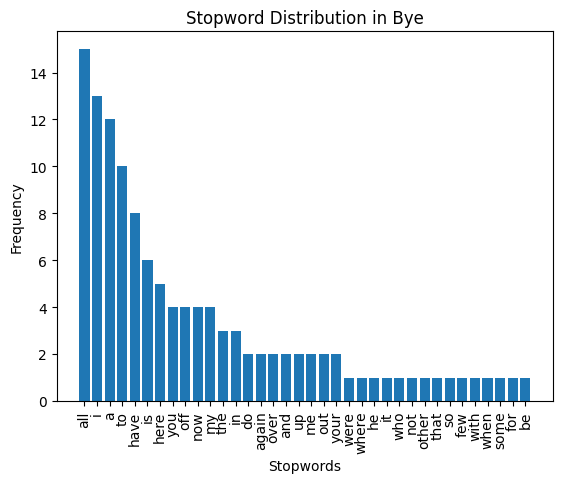

Clarify
proportion of stopwords to tokens in Clarify: 0.21359223300970873
[('i', 9), ('you', 3), ('the', 2), ('too', 1), ('my', 1), ('are', 1), ('him', 1), ('to', 1), ('a', 1), ('or', 1), ('not', 1)]


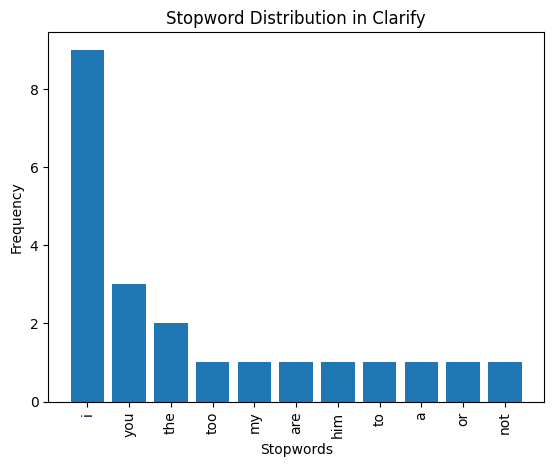

Emphasis
proportion of stopwords to tokens in Emphasis: 0.25017277125086385
[('i', 43), ('you', 26), ('it', 17), ('a', 16), ('the', 14), ('to', 11), ('my', 10), ('me', 10), ('in', 9), ('that', 8), ('your', 8), ('on', 8), ('here', 7), ('of', 6), ('have', 6), ('now', 6), ('is', 6), ('can', 6), ('its', 6), ('just', 5), ('all', 4), ('and', 4), ('this', 4), ('so', 4), ('what', 4), ('up', 4), ('with', 4), ('did', 4), ('for', 4), ('an', 4), ('are', 4), ('at', 4), ('while', 4), ('as', 4), ('no', 3), ('more', 3), ('has', 3), ('been', 3), ('am', 3), ('very', 3), ('he', 3), ('was', 3), ('his', 3), ('from', 3), ('do', 3), ('we', 3), ('than', 2), ('there', 2), ('then', 2), ('does', 2), ('over', 2), ('out', 2), ('too', 2), ('not', 2), ('once', 2), ('she', 2), ('where', 2), ('such', 1), ('again', 1), ('doing', 1), ('how', 1), ('off', 1), ('were', 1), ('him', 1), ('some', 1), ('if', 1), ('will', 1), ('who', 1), ('her', 1), ('same', 1), ('any', 1), ('about', 1), ('or', 1), ('them', 1), ('don', 1), ('t'

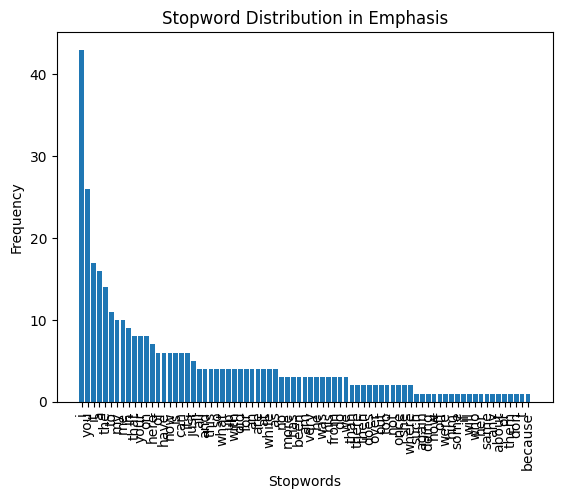

nAnswer
proportion of stopwords to tokens in nAnswer: 0.46474358974358976
[('no', 48), ('i', 17), ('not', 12), ('the', 5), ('a', 5), ('to', 5), ('me', 3), ('in', 3), ('here', 3), ('can', 2), ('it', 2), ('but', 2), ('did', 2), ('you', 2), ('with', 2), ('is', 2), ('from', 2), ('was', 2), ('that', 2), ('of', 2), ('just', 2), ('and', 2), ('again', 1), ('do', 1), ('an', 1), ('them', 1), ('other', 1), ('on', 1), ('o', 1), ('he', 1), ('this', 1), ('out', 1), ('for', 1), ('had', 1), ('who', 1), ('only', 1), ('am', 1), ('its', 1), ('any', 1), ('have', 1)]


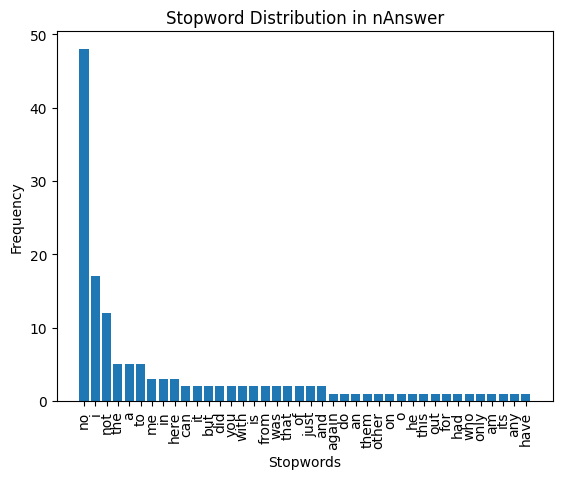

Other
proportion of stopwords to tokens in Other: 0.04054054054054054
[('a', 1), ('he', 1), ('m', 1)]


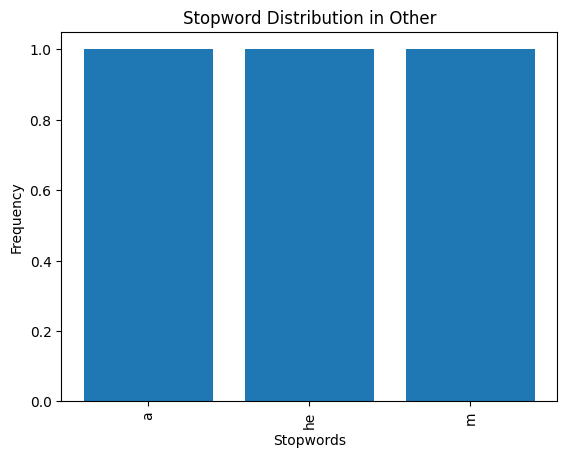

In [6]:
# task 1.1
# stopwords in a given dialogue act
# proportion of stopwords to tokens in dialogue act
actStopWordStats = ()
for act in dialogueGroups.keys():
    print(act)
    stopWordsFound, proportion = stopwordStats.StopWordCountDict(dialogueGroups[act])
    print(f'proportion of stopwords to tokens in {act}: {proportion}')
    print(stopWordsFound)
    word, freq = zip(*stopWordsFound)
    
    # histogram of stopwords in dialogue act
    plt.bar(word, freq)
    plt.xlabel('Stopwords')
    plt.xticks(rotation=90)
    plt.ylabel('Frequency')
    plt.title(f'Stopword Distribution in {act}')
    plt.show()

                 now      with      this      that       are        me  \
Statement   0.003065  0.003405  0.002043  0.009048  0.002821  0.014350   
System      0.000526  0.003025  0.003157  0.001973  0.000132  0.000789   
Greet       0.000291  0.000000  0.000000  0.000000  0.000873  0.001164   
whQuestion  0.000919  0.002452  0.001226  0.006436  0.021453  0.004597   
ynQuestion  0.001053  0.008950  0.001579  0.005265  0.009476  0.015530   
yAnswer     0.002387  0.002387  0.004773  0.004773  0.000000  0.007160   
Bye         0.005706  0.001427  0.000000  0.001427  0.000000  0.002853   
Emphasis    0.004147  0.002764  0.002764  0.005529  0.002764  0.006911   
Accept      0.000000  0.003546  0.001182  0.011820  0.003546  0.010638   
Reject      0.000000  0.005488  0.001098  0.012075  0.004391  0.013172   
Continuer   0.000000  0.004777  0.001592  0.007962  0.000000  0.007962   
nAnswer     0.000000  0.006410  0.003205  0.006410  0.000000  0.009615   
Emotion     0.000000  0.000000  0.0003

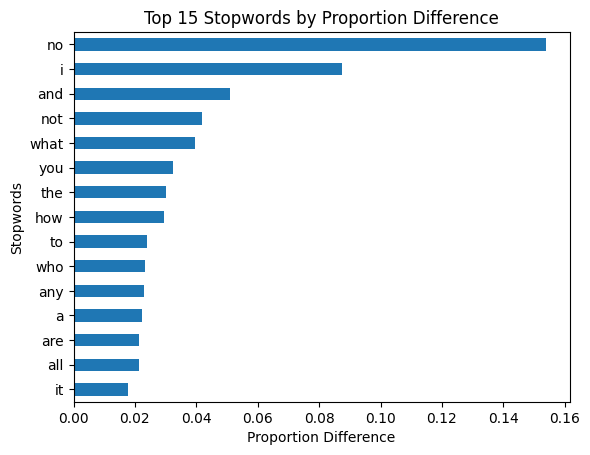

In [8]:
# task 1.2
# analysis with null hypothesis testing
# H0: stopwords are uniformly distributed across dialogue acts
# H1: stopwords are not uniformly distributed across dialogue acts

#Create a proportionality matrix of stopwords across dialogue acts
propDf = stopwordStats.ProportionalityMatrix(dialogueGroups)
print(propDf)

#visualize the top 15 stopwords by proportion difference across dialogue acts
diff = propDf.max(axis=0) - propDf.min(axis=0)
top15 = diff.sort_values(ascending=False).head(15)
top15.sort_values(ascending=True).plot(kind='barh')
plt.xlabel('Proportion Difference')
plt.ylabel('Stopwords')
plt.title('Top 15 Stopwords by Proportion Difference')
plt.show()

In [9]:
# task 2 

# head/tail break for most frequent tokens in dialogue act used
for act in dialogueGroups.keys():
    proportion, cutoff = stopwordStats.StopWordPropToFreqTokens(dialogueGroups[act])
    print(f'stopword proportion for most frequent tokens {act}: {proportion}')
    print(f'cutoff frequency for {act}: {cutoff}')

stopword proportion for most frequent tokens Statement: 0.01694915254237288
cutoff frequency for Statement: 1.0367838541666667
stopword proportion for most frequent tokens Emotion: 0.0
cutoff frequency for Emotion: 1.9101899827288429
stopword proportion for most frequent tokens System: 0.0
cutoff frequency for System: 4.776769509981851
stopword proportion for most frequent tokens Greet: 0.0
cutoff frequency for Greet: 1.3310546875
stopword proportion for most frequent tokens Accept: 0.0
cutoff frequency for Accept: 1.1948717948717948
stopword proportion for most frequent tokens Reject: 0.5
cutoff frequency for Reject: 1.0127388535031847
stopword proportion for most frequent tokens whQuestion: 0.16666666666666666
cutoff frequency for whQuestion: 1.0430528375733856
stopword proportion for most frequent tokens Continuer: 0.16666666666666666
cutoff frequency for Continuer: 1.0566037735849056
stopword proportion for most frequent tokens ynQuestion: 0.0
cutoff frequency for ynQuestion: 1.018

In [ ]:
# task 3


In [ ]:
#task 4



In [ ]:
# task 5



In [ ]:
# task 6



In [ ]:
#task 7



In [ ]:
# task 8



In [ ]:
# task 9



In [ ]:
# task 10



In [ ]:
# any comments 

